In [7]:
import os
import pandas as pd
import rioxarray as riox
import xarray as xr
from rasterio.plot import show

In [2]:
inDIR = '/90daydata/cper_neon_aop/hls_nrt/zarr/soap'
inFILE = 'soap_spatial_2024.zarr'

In [3]:
ds = xr.open_dataset(os.path.join(inDIR, inFILE))

/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [4]:
ds

<xarray.Dataset>
Dimensions:      (date: 52, y: 370, x: 429)
Coordinates:
  * date         (date) datetime64[ns] 2024-01-07 2024-01-14 ... 2024-12-29
    spatial_ref  int64 ...
  * x            (x) float64 -1.171e+07 -1.171e+07 ... -1.169e+07 -1.169e+07
  * y            (y) float64 5.012e+06 5.012e+06 ... 4.998e+06 4.997e+06
Data variables:
    BARE         (date, y, x) float32 ...
    Biomass      (date, y, x) float32 ...
    Biomass_SE   (date, y, x) float32 ...
    CP           (date, y, x) float32 ...
    DRYVEG       (date, y, x) float32 ...
    GREEN        (date, y, x) float32 ...
    LITT         (date, y, x) float32 ...
    NDVI         (date, y, x) float32 ...
    NONVEG       (date, y, x) float32 ...
    SD           (date, y, x) float32 ...
Attributes:
    _FillValue:  3.402823466385289e+38

In [5]:
da = ds['Biomass'].sel(date=ds['date'][ds['date'].dt.month==6][-1])
da

<xarray.DataArray 'Biomass' (y: 370, x: 429)>
[158730 values with dtype=float32]
Coordinates:
    date         datetime64[ns] 2024-06-30
    spatial_ref  int64 0
  * x            (x) float64 -1.171e+07 -1.171e+07 ... -1.169e+07 -1.169e+07
  * y            (y) float64 5.012e+06 5.012e+06 ... 4.998e+06 4.997e+06

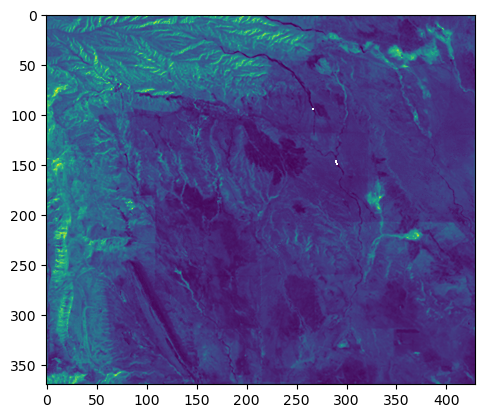

<AxesSubplot:>

In [9]:
show(da.data)

In [6]:
da.rio.to_raster('./outputs/soap_biomass_2024_06_30.tif')